# OMI inversion: stage latents, mapped priors, and visual inspection
Run cells sequentially with `/opt/anaconda3/envs/manip311/bin/python` as the Jupyter kernel, outside the Codex sandbox for MPS. This notebook imports the project's generator loader and synthesis helper; it does not run inversion or modify checkpoints.

The controls below select checkpoint folders, mapping model, Z prior, and rendering models independently. Checkpoints currently live in **`tests/`**, not `test/`; discovery checks both. New partial checkpoints contribute only their `completed_images` prefix. Older checkpoints without that field are treated as completed stages.

“Uniform Z” here means independent coordinates from U(−1, 1), a **cube**, not a sphere. A uniform-sphere option is included. Gaussian Z is also sampled because `CandidateDistribution.from_generator` in the inversion code uses `torch.randn`. These priors should not be conflated.


In [41]:
from pathlib import Path
import gc
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image, ImageOps
from IPython.display import display

PROJECT_ROOT = Path('/Users/adamsobieszek/PycharmProjects/psych_gen_app')
VAE_ROOT = Path('/Users/adamsobieszek/PycharmProjects/VAE-Traversals')
sys.path.insert(0, str(VAE_ROOT))
from face_analysis.match_lpips_folders import (
    load_generator, synthesize, select_device, release_device_cache, MODEL_RESOLUTIONS,
)
from face_analysis.natural_gradient_inversion import CandidateDistribution

CHECKPOINT_DIRS = [PROJECT_ROOT / 'test', PROJECT_ROOT / 'tests']
# Set this to the local image root if the original /workspace/... paths are unavailable.
IMAGE_ROOT =   Path('/Users/adamsobieszek/PycharmProjects/psychGAN/omi/images')
MODEL_ROOT = VAE_ROOT / 'train_traversals/models/pretrained/generators/StyleGAN2'
MODEL_CHECKPOINTS = {
    '128': MODEL_ROOT / 'sg128_pointwise_style32.pt',
    '256': MODEL_ROOT / 'sg256_pointwise_style32.pt',
    'full': MODEL_ROOT / 'stylegan2-ffhq-config-f.pt',
}
MAPPING_MODEL = 'full'        # Mapping used for reference samples and truncation center.
PRIORS = ['uniform_cube', 'gaussian']  # Optionally add 'uniform_sphere'.
PRIMARY_PRIOR = 'uniform_cube'
N_REFERENCE = 8192
MAPPING_BATCH = 256
SEED = 20260917
PSI_GRID = np.linspace(0, 2, 101)  # ψ > 1 expands instead of truncating.
N_DIRECTIONS = 96
N_QUANTILES = 512
DEVICE = select_device('auto')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('Device:', DEVICE, '| mapping model:', MAPPING_MODEL)


Device: mps | mapping model: full


## 1. Load stage checkpoints and exclude unfinished rows
Reload this cell while inversion is running to pick up the most recent atomic save. The `w` tensor in a partial file also contains initialization/previous-stage values after the completed prefix; those are **not** results of that stage. Path identities are retained for pairing stages.


In [13]:
def read_stage(path):
    payload = torch.load(path, map_location='cpu', weights_only=True)
    w = payload['w'].detach().float().cpu()
    if w.ndim != 2 or w.shape[1] != 512:
        raise ValueError(f'{path}: expected shared W [N, 512], got {tuple(w.shape)}')
    completed = payload.get('completed_images', len(w))
    if not isinstance(completed, int) or not 0 <= completed <= len(w):
        raise ValueError(f'{path}: invalid completed_images={completed}')
    names = payload.get('paths')
    if names is None or len(names) != len(w) or len(set(names)) != len(names):
        raise ValueError(f'{path}: expected one unique source path per W row')
    w = w[:completed].numpy().copy()
    if not np.isfinite(w).all():
        raise ValueError(f'{path}: completed rows contain non-finite values')
    return dict(file=path, w=w, paths=list(names[:completed]), total=len(names),
                completed=completed, model=payload['stage_model'],
                algorithm=payload.get('algorithm', 'legacy / unspecified'))

stage_files = sorted({p.resolve() for folder in CHECKPOINT_DIRS
                      for p in folder.glob('stage_[0-9][0-9]_*.pt')})
if not stage_files:
    raise FileNotFoundError(f'No stage checkpoints in {CHECKPOINT_DIRS}')
stages = {}
for p in stage_files:
    label = p.stem
    if label in stages:
        label = f'{p.parent.name}/{label}'
    stages[label] = read_stage(p)
stage_table = pd.DataFrame([
    dict(stage=k, model=s['model'], completed=s['completed'], total=s['total'],
         fraction=s['completed'] / s['total'], algorithm=s['algorithm'], file=str(s['file']))
    for k, s in stages.items()
]).set_index('stage')
display(stage_table)
SELECTED_STAGE = list(stages)[-1]


,model,completed,total,fraction,algorithm,file
stage,,,,,,
stage_01_128,128,3039,3039,1.000000,legacy / unspecified,/Users/adamsobieszek/PycharmProjects/psych_gen...
stage_02_256,256,3039,3039,1.000000,legacy / unspecified,/Users/adamsobieszek/PycharmProjects/psych_gen...
stage_03_full,full,1380,3039,0.454097,natural_gradient_v1,/Users/adamsobieszek/PycharmProjects/psych_gen...


## 2. Load one generator at a time; sample reference distributions
The cache retains only the currently selected generator to limit GPU/MPS memory. Gaussian sampling uses the inversion module's `CandidateDistribution`; uniform sampling calls the same generator mapping directly with ψ = 1. Shared W is the first mapped style, before synthesis.

Reference banks are generated once and reused for every ψ, avoiding additional Monte Carlo noise across the scan. Set `MAPPING_MODEL` to `128`, `256`, or `full` and rerun from here to compare another mapping. Rendering with a different decoder does not change these reference banks.


In [14]:
_loaded_model = None
_generator = None

def get_generator(model):
    global _loaded_model, _generator
    if _loaded_model != model:
        _generator = None
        _loaded_model = None
        gc.collect()
        release_device_cache(DEVICE)
        _generator = load_generator(model, MODEL_CHECKPOINTS[model], DEVICE)
        _loaded_model = model
    return _generator

@torch.inference_mode()
def sample_uniform_w(generator, prior, count, seed):
    rng = torch.Generator(device='cpu').manual_seed(seed)
    pieces = []
    for start in range(0, count, MAPPING_BATCH):
        n = min(MAPPING_BATCH, count - start)
        if prior == 'uniform_cube':
            z = torch.rand(n, generator.z_dim, generator=rng) * 2 - 1
        elif prior == 'uniform_sphere':
            z = torch.randn(n, generator.z_dim, generator=rng)
            z = z / z.norm(dim=1, keepdim=True).clamp_min(1e-12)
        else:
            raise ValueError(prior)
        mapped = generator.mapping(z.to(DEVICE), None, truncation_psi=1.0)
        pieces.append(mapped[:, 0].float().cpu())
    return torch.cat(pieces).numpy()

assert N_REFERENCE >= 16 and PRIMARY_PRIOR in PRIORS
generator = get_generator(MAPPING_MODEL)
W_AVG = generator.mapping.w_avg.detach().float().cpu().numpy().reshape(-1).copy()
reference = {}
for prior in PRIORS:
    if prior == 'gaussian':
        torch.manual_seed(SEED)
        bank = CandidateDistribution.from_generator(
            generator, num_samples=N_REFERENCE, batch_size=MAPPING_BATCH,
            truncation_psi=1.0, device=DEVICE,
        ).to('cpu')
        reference[prior] = bank.samples.numpy().copy()
        del bank
    else:
        reference[prior] = sample_uniform_w(generator, prior, N_REFERENCE, SEED)
del generator  # Keep only the managed cache's reference to the model.
print({k: v.shape for k, v in reference.items()})


{'uniform_cube': (8192, 512), 'gaussian': (8192, 512)}


## 3. Radius, center shift, covariance shape
For cloud X, its center of mass is μₓ = mean(X), and its centered RMS radius is Rₓ = √mean‖x−μₓ‖². The ratio **R_inverted / R_reference** is a moment-based ψ estimate because positive truncation scales centered radii by ψ. Mean and median radius ratios are also reported.

Actual StyleGAN truncation uses the model's stored center **a = `mapping.w_avg`**:

**w(ψ) = a + ψ(w(1) − a)**.

Distances to a are reported separately: they combine spread and center displacement. Equal radii alone do not imply equal distributions. Effective covariance rank and normalized covariance-shape differences test aspects that a single ψ cannot fix. All moments below use population normalization (divide by N).


In [15]:
def radii(x, center=None):
    return np.linalg.norm(x - (x.mean(axis=0) if center is None else center), axis=1)

def rms(x):
    return float(np.sqrt(np.mean(np.square(x))))

def covariance(x):
    centered = np.asarray(x, dtype=np.float64) - x.mean(axis=0, dtype=np.float64)
    return centered.T @ centered / len(x)

def cloud_stats(x):
    c = covariance(x)
    trace = np.trace(c)
    return dict(n=len(x), mean_radius=float(radii(x).mean()),
                median_radius=float(np.median(radii(x))), rms_radius=rms(radii(x)),
                rms_to_w_avg=rms(radii(x, W_AVG)),
                com_to_w_avg=float(np.linalg.norm(x.mean(0) - W_AVG)),
                effective_rank=float(trace**2 / max(np.square(c).sum(), 1e-20)))

clouds = {f'reference/{p}': x for p, x in reference.items()}
clouds.update({name: s['w'] for name, s in stages.items() if s['completed'] >= 2})
summary = pd.DataFrame({name: cloud_stats(x) for name, x in clouds.items()}).T
display(summary)
ratio_rows = []
for name, s in stages.items():
    if s['completed'] < 2:
        continue
    x = s['w']
    cx = covariance(x)
    for prior, y in reference.items():
        cy = covariance(y)
        ratio_rows.append(dict(
            stage=name, prior=prior,
            psi_rms=rms(radii(x)) / rms(radii(y)),
            mean_radius_ratio=radii(x).mean() / radii(y).mean(),
            median_radius_ratio=np.median(radii(x)) / np.median(radii(y)),
            rms_to_w_avg_ratio=rms(radii(x, W_AVG)) / rms(radii(y, W_AVG)),
            com_distance_in_reference_radii=np.linalg.norm(x.mean(0)-y.mean(0)) / rms(radii(y)),
            covariance_shape_gap=np.linalg.norm(cx / np.trace(cx) - cy / np.trace(cy), 'fro'),
        ))
radius_ratios = pd.DataFrame(ratio_rows).set_index(['stage', 'prior'])
display(radius_ratios)


,n,mean_radius,median_radius,rms_radius,rms_to_w_avg,com_to_w_avg,effective_rank
reference/uniform_cube,8192.0,9.828072,9.641649,9.980692,9.984321,0.269174,31.844693
reference/gaussian,8192.0,9.874340,9.656984,10.030112,10.033477,0.259795,31.315736
stage_01_128,3039.0,5207.830078,2604.767334,143569.218750,143592.843750,2605.025635,1.000000
stage_02_256,3039.0,5207.832031,2604.759766,143569.218750,143592.843750,2605.073242,1.000000
stage_03_full,1380.0,11.350290,10.828203,11.563061,12.104810,3.580788,81.151879


psi_rms  mean_radius_ratio  \
stage         prior                                           
stage_01_128  uniform_cube  14384.695976         529.893372   
              gaussian      14313.819720         527.410461   
stage_02_256  uniform_cube  14384.695976         529.893555   
              gaussian      14313.819720         527.410645   
stage_03_full uniform_cube      1.158543           1.154885   
              gaussian          1.152835           1.149473   

                            median_radius_ratio  rms_to_w_avg_ratio  \
stage         prior                                                   
stage_01_128  uniform_cube           270.157867        14381.834170   
              gaussian               269.728851        14311.374431   
stage_02_256  uniform_cube           270.157074        14381.834170   
              gaussian               269.728058        14311.374431   
stage_03_full uniform_cube             1.123065            1.212382   
              gaussian                 1.121282            1.206442   

                            com_distance_in_reference_radii  \
stage         prior                                           
stage_01_128  uniform_cube                       261.006561   
              gaussian                           259.719482   
stage_02_256  uniform_cube                       261.011322   
              gaussian                           259.724243   
stage_03_full uniform_cube                         0.361434   
              gaussian                             0.359029   

                            covariance_shape_gap  
stage         prior                               
stage_01_128  uniform_cube              1.013674  
              gaussian                  1.014024  
stage_02_256  uniform_cube              1.013674  
              gaussian                  1.014024  
stage_03_full uniform_cube              0.107821  
              gaussian                  0.108785

## 4. Estimate ψ by projected distribution matching; validate on unused images
Use deterministic random unit directions. For each direction, approximate projected quantile functions on a fixed probability grid. The average squared quantile difference estimates **sliced Wasserstein-2 squared** (SW₂²). The reported SW₂ is in projected W units, not full-dimensional Euclidean distance.

Half the inverted images and half the reference bank select ψ. Since ψ ≥ 0 preserves quantile order, minimizing this objective has a scalar least-squares solution. We also plot a grid scan. The other halves provide a held-out discrepancy. A size-matched reference-versus-reference baseline at the fitted ψ indicates finite-sample noise; it is not a formal goodness-of-fit test. Baseline ratio near 1 is encouraging, but does not prove equality.

Fitting after subtracting each cloud's own mean estimates spread/shape ψ separately from center placement. If that ψ, the uncentered fit, and the radius ratio disagree, a single truncation parameter is inadequate. ψ > 1 means expansion; a boundary optimum suggests extending the grid. The selected ψ depends on the chosen metric and prior.


psi_fit  psi_centered_fit  train_SW2  \
stage         prior                                                 
stage_01_128  uniform_cube  1.241423          1.242046   0.155421   
              gaussian      1.230024          1.232340   0.158264   
stage_02_256  uniform_cube  1.249567          1.250530   0.169516   
              gaussian      1.238315          1.240829   0.171852   
stage_03_full uniform_cube  1.150640          1.151391   0.154882   
              gaussian      1.140191          1.142418   0.157173   

                            heldout_SW2  heldout_SW2_psi1  \
stage         prior                                         
stage_01_128  uniform_cube     0.162721          0.190544   
              gaussian         0.162650          0.189949   
stage_02_256  uniform_cube     0.176890          0.205105   
              gaussian         0.177082          0.204690   
stage_03_full uniform_cube     0.154396          0.168846   
              gaussian         0.154846          0.168663   

                            reference_baseline_SW2  heldout_over_baseline  \
stage         prior                                                         
stage_01_128  uniform_cube                0.031624               5.145557   
              gaussian                    0.029112               5.587022   
stage_02_256  uniform_cube                0.031831               5.557157   
              gaussian                    0.029308               6.042018   
stage_03_full uniform_cube                0.039455               3.913219   
              gaussian                    0.035371               4.377803   

                            residual_mean_distance  baseline_size_matched  \
stage         prior                                                         
stage_01_128  uniform_cube             5208.082031                   True   
              gaussian                 5208.078125                   True   
stage_02_256  uniform_cube             5208.126953                   True   
              gaussian                 5208.123047                   True   
stage_03_full uniform_cube                3.666425                   True   
              gaussian                    3.651889                   True   

                            at_grid_boundary       psi_rms  mean_radius_ratio  
stage         prior                                                            
stage_01_128  uniform_cube             False  14384.695976         529.893372  
              gaussian                 False  14313.819720         527.410461  
stage_02_256  uniform_cube             False  14384.695976         529.893555  
              gaussian                 False  14313.819720         527.410645  
stage_03_full uniform_cube             False      1.158543           1.154885  
              gaussian                 False      1.152835           1.149473

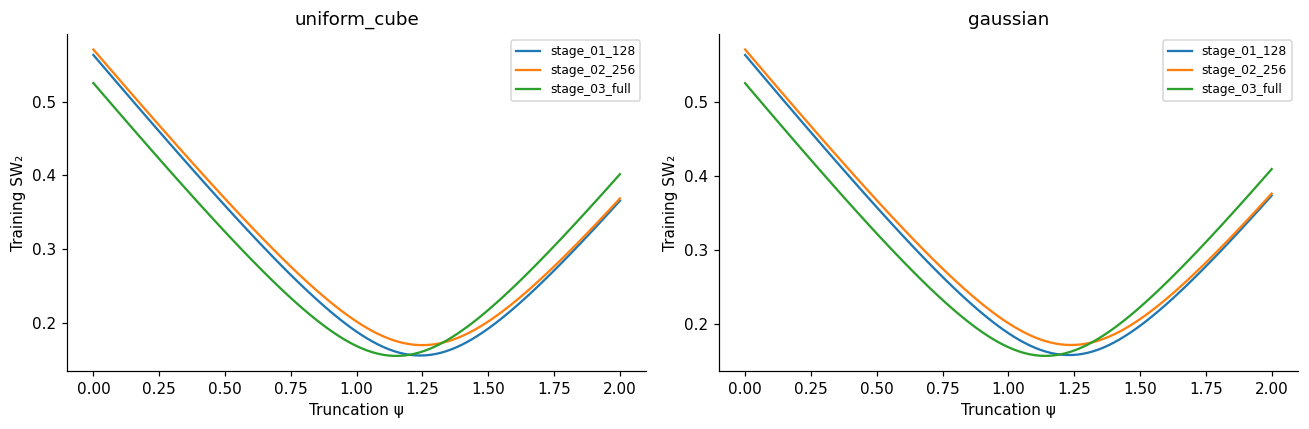

In [46]:
rng = np.random.default_rng(SEED)
directions = rng.normal(size=(512, N_DIRECTIONS))
directions /= np.linalg.norm(directions, axis=0, keepdims=True)
quantile_levels = (np.arange(N_QUANTILES) + 0.5) / N_QUANTILES
anchor_projection = W_AVG @ directions

def projected_quantiles(x):
    return np.quantile(x @ directions, quantile_levels, axis=0)

def split_cloud(x, seed):
    order = np.random.default_rng(seed).permutation(len(x))
    mid = len(x) // 2
    return x[order[:mid]], x[order[mid:]]

def fit_scale(qx, qy, anchor):
    dx, dy = qx - anchor, qy - anchor
    return float(np.clip(np.mean(dx * dy) / max(np.mean(dy * dy), 1e-20),
                         PSI_GRID[0], PSI_GRID[-1]))

def sw2(qx, qy):
    return float(np.sqrt(np.mean((qx - qy)**2)))

reference_splits = {p: split_cloud(y, SEED + 1) for p, y in reference.items()}
reference_quantiles = {p: tuple(projected_quantiles(v) for v in split)
                       for p, split in reference_splits.items()}
fits, scan_curves = [], {}
for name, s in stages.items():
    if len(s['w']) < 8:
        print('Too few completed images for split fitting:', name)
        continue
    x_train, x_test = split_cloud(s['w'], SEED + 2)
    qx_train, qx_test = projected_quantiles(x_train), projected_quantiles(x_test)
    for prior, (y_train, y_test) in reference_splits.items():
        qy_train, qy_test = reference_quantiles[prior]
        psi = fit_scale(qx_train, qy_train, anchor_projection)
        centered_psi = fit_scale(qx_train - x_train.mean(0) @ directions,
                                 qy_train - y_train.mean(0) @ directions, 0.0)
        fitted_test = anchor_projection + psi * (qy_test - anchor_projection)
        heldout = sw2(qx_test, fitted_test)
        # Same row counts as the held-out inverted-vs-reference comparison.
        n_baseline = min(len(x_test), len(y_train))
        baseline_q = projected_quantiles(y_train[:n_baseline])
        baseline = sw2(anchor_projection + psi * (baseline_q - anchor_projection), fitted_test)
        fitted_mean = W_AVG + psi * (y_test.mean(0) - W_AVG)
        fits.append(dict(
            stage=name, prior=prior, psi_fit=psi, psi_centered_fit=centered_psi,
            train_SW2=sw2(qx_train, anchor_projection + psi * (qy_train-anchor_projection)),
            heldout_SW2=heldout, heldout_SW2_psi1=sw2(qx_test, qy_test),
            reference_baseline_SW2=baseline,
            heldout_over_baseline=heldout / baseline if baseline > 0 else np.nan,
            residual_mean_distance=float(np.linalg.norm(x_test.mean(0)-fitted_mean)),
            baseline_size_matched=(n_baseline == len(x_test)),
            at_grid_boundary=bool(np.isclose(psi, PSI_GRID[[0, -1]]).any()),
        ))
        scan_curves[(name, prior)] = [
            sw2(qx_train, anchor_projection + p * (qy_train-anchor_projection)) for p in PSI_GRID
        ]
fit_table = pd.DataFrame(fits).set_index(['stage', 'prior'])
display(fit_table.join(radius_ratios[['psi_rms', 'mean_radius_ratio']]))

fig, axes = plt.subplots(1, len(PRIORS), figsize=(6*len(PRIORS), 4), squeeze=False)
for ax, prior in zip(axes.flat, PRIORS):
    for (name, p), scores in scan_curves.items():
        if p == prior:
            ax.plot(PSI_GRID, scores, label=name)
    ax.set(title=prior, xlabel='Truncation ψ', ylabel='Training SW₂')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 5. Selected stage: radius distributions and Q–Q comparisons
Change `SELECTED_STAGE` or `PRIMARY_PRIOR` here and rerun subsequent cells. Own-center distances show spread; distances to `w_avg` also show displacement. Q–Q curves on the diagonal indicate matching radial distributions, which still do not establish matching angular structure.


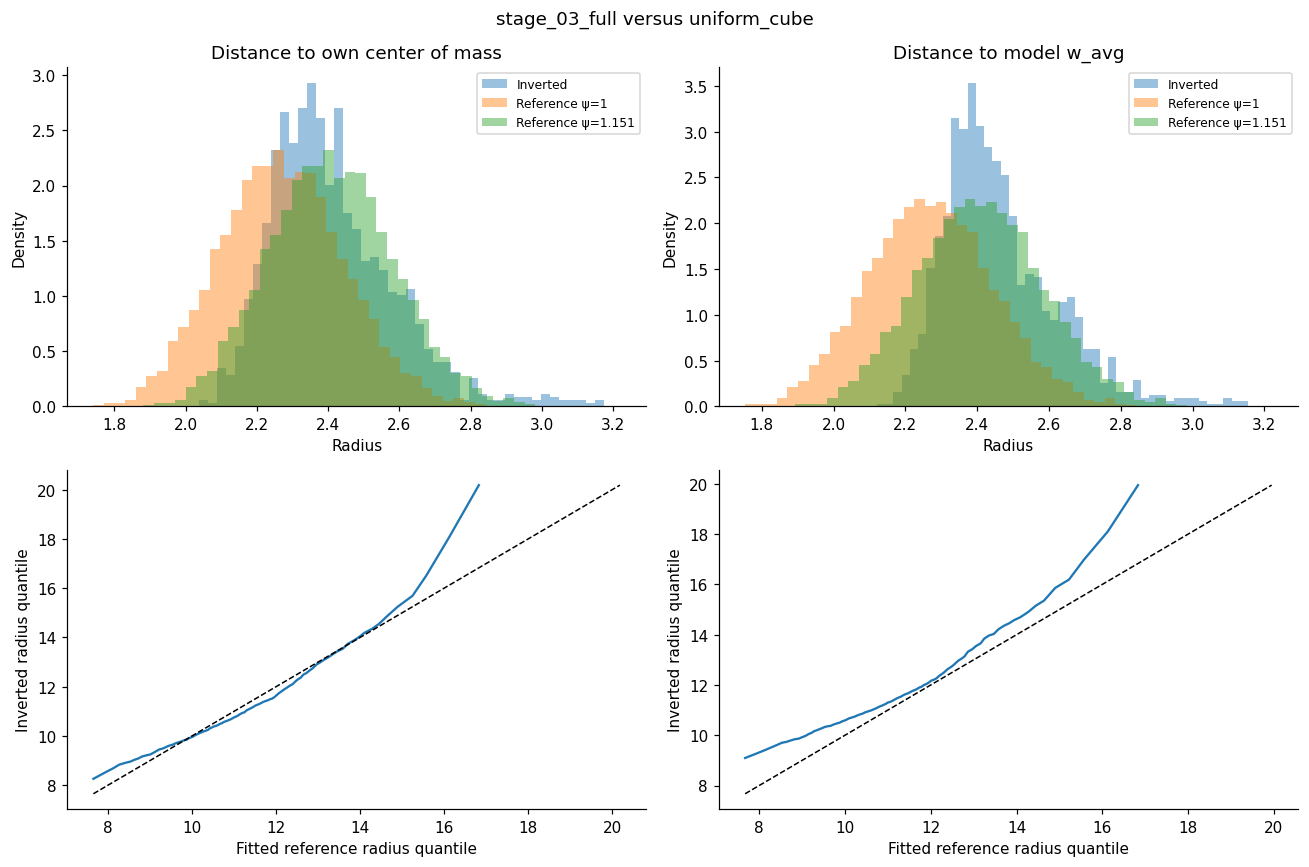

In [51]:
# SELECTED_STAGE = 'stage_03_full'
# PRIMARY_PRIOR = 'uniform_cube'
x = stages[SELECTED_STAGE]['w']
y = reference[PRIMARY_PRIOR]
psi_best = float(fit_table.loc[(SELECTED_STAGE, PRIMARY_PRIOR), 'psi_fit'])
y_fit = W_AVG + psi_best * (y - W_AVG)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, (center, title) in enumerate([(None, 'Distance to own center of mass'),
                                      (W_AVG, 'Distance to model w_avg')]):
    rx, ry, rf = radii(x, center), radii(y, center), radii(y_fit, center)
    for values, label in [(rx, 'Inverted'), (ry, 'Reference ψ=1'),
                           (rf, f'Reference ψ={psi_best:.3f}')]:
        axes[0, col].hist(np.log(values), bins=45, density=True, alpha=.45, label=label)
    axes[0, col].set(title=title, xlabel='Radius', ylabel='Density')
    axes[0, col].legend(fontsize=8)
    q = np.linspace(.01, .99, 99)
    qx, qf = np.quantile(rx, q), np.quantile(rf, q)
    axes[1, col].plot(qf, qx)
    lo, hi = min(qx.min(), qf.min()), max(qx.max(), qf.max())
    axes[1, col].plot([lo, hi], [lo, hi], 'k--', lw=1)
    axes[1, col].set(xlabel='Fitted reference radius quantile', ylabel='Inverted radius quantile')
fig.suptitle(f'{SELECTED_STAGE} versus {PRIMARY_PRIOR}')
plt.tight_layout()
plt.show()


## 6. Shared PCA, covariance spectrum, and directional variability
PCA axes come **only from the untruncated reference**; both clouds use its mean and axes. A scalar ψ rescales covariance eigenvalues uniformly but leaves their normalized spectrum unchanged. The variance-ratio plot uses those same reference axes, avoiding misleading comparisons between separately rotated PCs. These plots use all completed rows descriptively; the previous cell's validation remains the held-out comparison.


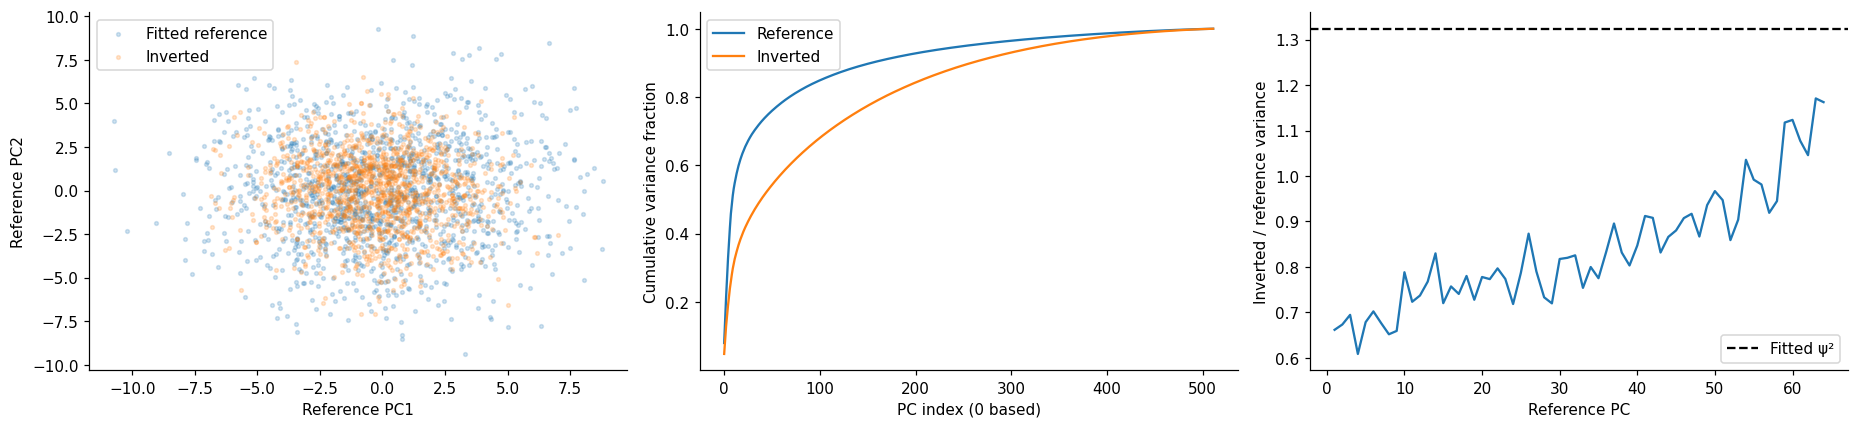

In [18]:
reference_cov = covariance(y)
eigenvalues, eigenvectors = np.linalg.eigh(reference_cov)
order = np.argsort(eigenvalues)[::-1]
eigenvalues, basis = np.maximum(eigenvalues[order], 0), eigenvectors[:, order]
mean_ref = y.mean(0)
x_pca, y_pca = (x-mean_ref) @ basis, (y_fit-mean_ref) @ basis
inverted_eigenvalues = np.maximum(np.linalg.eigvalsh(covariance(x))[::-1], 0)
show = min(2000, len(x), len(y_fit))
rng_plot = np.random.default_rng(SEED)
ix = rng_plot.choice(len(x), show, replace=False)
iy = rng_plot.choice(len(y_fit), show, replace=False)
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].scatter(y_pca[iy, 0], y_pca[iy, 1], s=6, alpha=.2, label='Fitted reference')
axes[0].scatter(x_pca[ix, 0], x_pca[ix, 1], s=6, alpha=.2, label='Inverted')
axes[0].set(xlabel='Reference PC1', ylabel='Reference PC2')
axes[0].legend()
axes[1].plot(np.cumsum(eigenvalues)/eigenvalues.sum(), label='Reference')
axes[1].plot(np.cumsum(inverted_eigenvalues)/inverted_eigenvalues.sum(), label='Inverted')
axes[1].set(xlabel='PC index (0 based)', ylabel='Cumulative variance fraction')
axes[1].legend()
variance_ratio = x_pca.var(axis=0) / np.maximum(eigenvalues, 1e-12)
axes[2].plot(np.arange(1, 65), variance_ratio[:64])
axes[2].axhline(psi_best**2, ls='--', color='black', label='Fitted ψ²')
axes[2].set(xlabel='Reference PC', ylabel='Inverted / reference variance')
axes[2].legend()
plt.tight_layout()
plt.show()


## 7. Paired changes between stages
Compare only identical source paths completed in both stages. These are within-image changes in W, not distances between independently sampled clouds. Comparing all of an earlier stage with a partial later stage may introduce image-selection effects; paired rows avoid that for this comparison.


,pair,paired_images,mean_change,median_change,p95_change,paired_center_shift,paired_radius_ratio
0,stage_01_128 → stage_02_256,3039,4.406914,4.220007,5.958435,1.150243,1.000000
1,stage_02_256 → stage_03_full,1380,0.833586,0.798045,1.171765,0.429721,0.972886


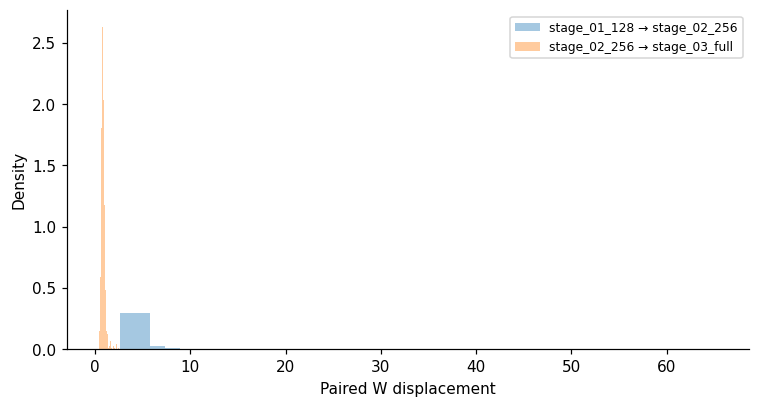

In [19]:
paired_rows = []
paired_distances = {}
ordered_stages = sorted(stages, key=lambda key: (['128', '256', 'full'].index(stages[key]['model']), key))
for left, right in zip(ordered_stages[:-1], ordered_stages[1:]):
    a, b = stages[left], stages[right]
    ia = {p: i for i, p in enumerate(a['paths'])}
    pairs = [(ia[p], j) for j, p in enumerate(b['paths']) if p in ia]
    if not pairs:
        continue
    ai, bi = np.asarray(pairs).T
    wa, wb = a['w'][ai], b['w'][bi]
    delta = np.linalg.norm(wb-wa, axis=1)
    label = f'{left} → {right}'
    paired_distances[label] = delta
    paired_rows.append(dict(pair=label, paired_images=len(pairs), mean_change=delta.mean(),
                           median_change=np.median(delta), p95_change=np.quantile(delta, .95),
                           paired_center_shift=np.linalg.norm(wb.mean(0)-wa.mean(0)),
                           paired_radius_ratio=rms(radii(wb))/max(rms(radii(wa)), 1e-12)))
display(pd.DataFrame(paired_rows))
if paired_distances:
    fig, ax = plt.subplots(figsize=(8, 4))
    for label, values in paired_distances.items():
        ax.hist(values, bins=40, alpha=.4, density=True, label=label)
    ax.set(xlabel='Paired W displacement', ylabel='Density')
    ax.legend(fontsize=8)
    plt.show()


## 8. Inspect low-, median-, and high-radius inverted faces with any decoder
Set `RENDER_MODELS` to any subset of `['128', '256', 'full']`. Each column renders the same W through a different generator, with constant synthesis noise and FP32. Selection spans distance to the inverted cloud's own center; set `INSPECT_INDICES` manually for particular completed rows. Missing originals are labeled, not silently replaced. Full-resolution generation is slower; batch size 2 limits memory.


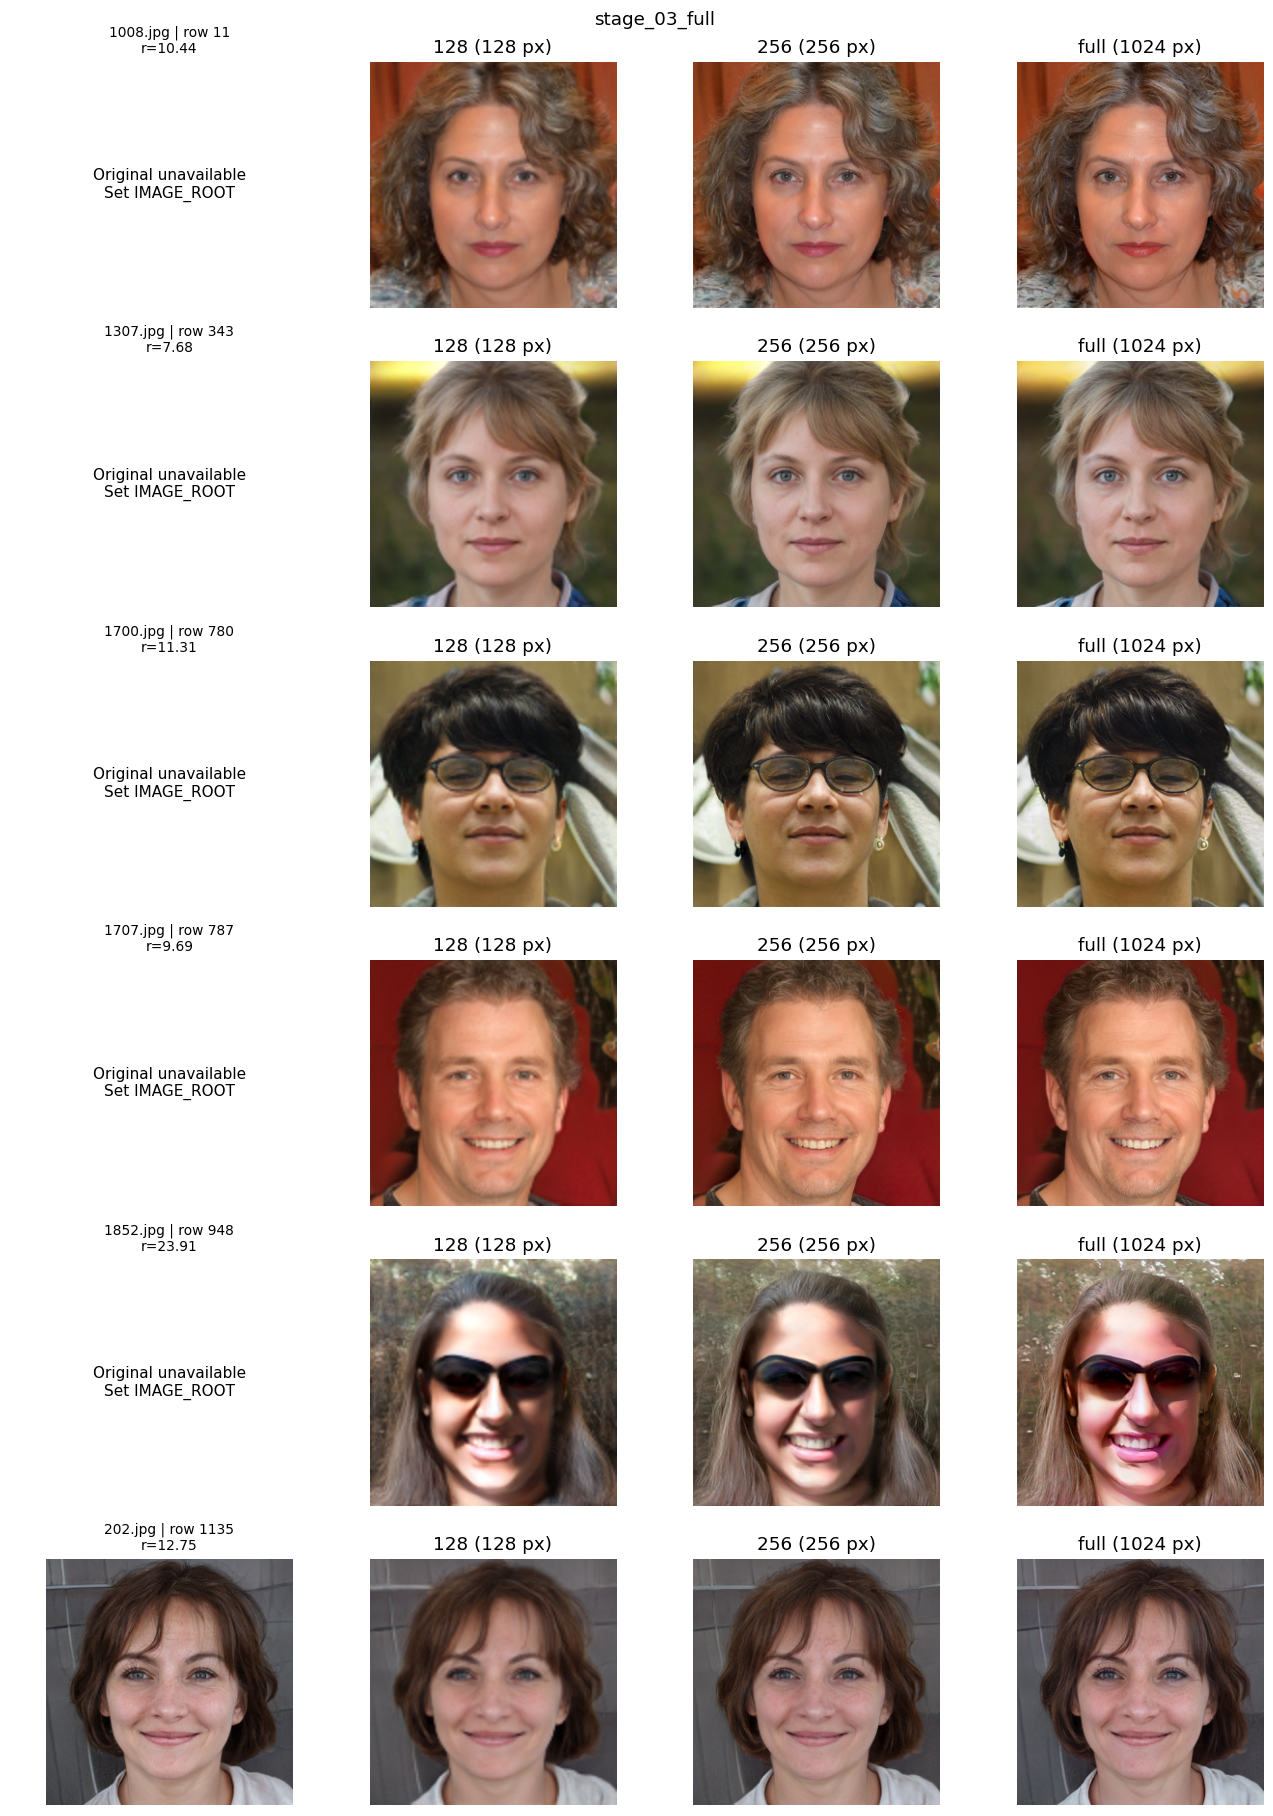

In [43]:
RENDER_MODELS = ['128', '256', 'full']
RENDER_BATCH = 2
THUMBNAIL_SIZE = 256
ranked = np.argsort(radii(x))
INSPECT_INDICES = np.unique(ranked[np.linspace(0, len(ranked)-1, min(6, len(ranked))).astype(int)])
# INSPECT_INDICES = np.array([0, 100, 500])

@torch.no_grad()
def render_ws(ws, model):
    g = get_generator(model)
    thumbnails = []
    for start in range(0, len(ws), RENDER_BATCH):
        batch = torch.as_tensor(np.array(ws[start:start+RENDER_BATCH], copy=True), device=DEVICE)
        images = synthesize(g, batch, noise_mode='const', precision='fp32')
        arrays = ((images.clamp(-1, 1)+1)*127.5).round().byte().permute(0, 2, 3, 1).cpu().numpy()
        thumbnails.extend(Image.fromarray(a).resize((THUMBNAIL_SIZE, THUMBNAIL_SIZE)) for a in arrays)
    return thumbnails

def source_image(source_path):
    original = Path(source_path)
    candidates = [original]
    if IMAGE_ROOT is not None:
        try:    
            #extract filename only
            candidates.append(IMAGE_ROOT /original.name)
        except ValueError:
            pass
        candidates.append(IMAGE_ROOT / original.name)
    for candidate in candidates:
        if candidate.is_file():
            with Image.open(candidate) as image:
                return ImageOps.exif_transpose(image).convert('RGB').resize((THUMBNAIL_SIZE, THUMBNAIL_SIZE))
    return None

selected_w = x[INSPECT_INDICES]
rendered = {model: render_ws(selected_w, model) for model in RENDER_MODELS}
fig, axes = plt.subplots(len(INSPECT_INDICES), len(RENDER_MODELS)+1,
                         figsize=(3*(len(RENDER_MODELS)+1), 2.8*len(INSPECT_INDICES)), squeeze=False)
for row, index in enumerate(INSPECT_INDICES):
    source = stages[SELECTED_STAGE]['paths'][index]
    original = source_image(source)
    if original is not None:
        axes[row, 0].imshow(original)
    else:
        axes[row, 0].text(.5, .5, 'Original unavailable\nSet IMAGE_ROOT', ha='center', va='center')
    axes[row, 0].set_title(f'{Path(source).name} | row {index}\nr={radii(x)[index]:.2f}', fontsize=9)
    for col, model in enumerate(RENDER_MODELS, 1):
        axes[row, col].imshow(rendered[model][row])
        axes[row, col].set_title(f'{model} ({MODEL_RESOLUTIONS[model]} px)')
for ax in axes.flat:
    ax.axis('off')
fig.suptitle(SELECTED_STAGE)
plt.tight_layout()
plt.show()


## 9. Inspect the same images across stages
This grid isolates inversion changes by using one decoder for every stage. It selects source paths completed in every checkpoint; each row is the same source image. Change `STAGE_RENDER_MODEL` to inspect with another decoder.


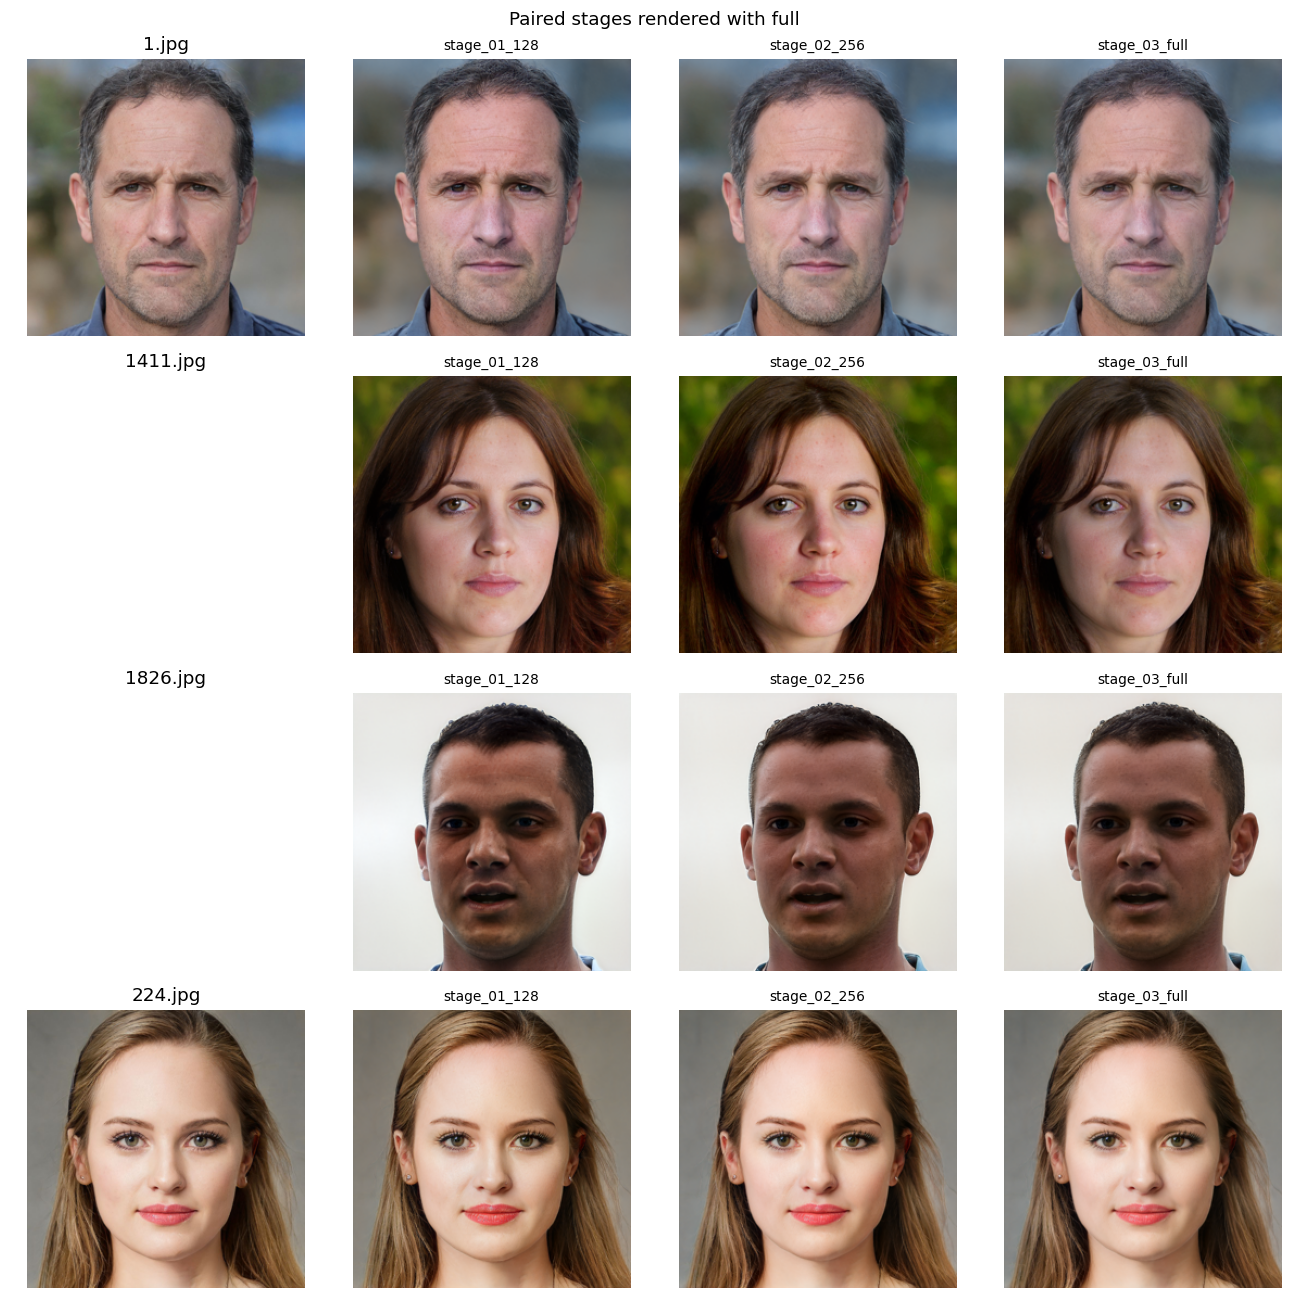

In [44]:
STAGE_RENDER_MODEL = 'full'
path_maps = {name: {p: i for i, p in enumerate(s['paths'])} for name, s in stages.items()}
common_paths = [p for p in stages[SELECTED_STAGE]['paths'] if all(p in m for m in path_maps.values())]
if common_paths:
    positions = np.linspace(0, len(common_paths)-1, min(4, len(common_paths))).astype(int)
    inspect_paths = [common_paths[i] for i in positions]
    fig, axes = plt.subplots(len(inspect_paths), len(stages)+1,
                             figsize=(3*(len(stages)+1), 3*len(inspect_paths)), squeeze=False)
    for row, p in enumerate(inspect_paths):
        original = source_image(p)
        if original is not None:
            axes[row, 0].imshow(original)
        axes[row, 0].set_title(Path(p).name)
    for col, name in enumerate(stages, 1):
        ws = stages[name]['w'][[path_maps[name][p] for p in inspect_paths]]
        images = render_ws(ws, STAGE_RENDER_MODEL)
        for row, image in enumerate(images):
            axes[row, col].imshow(image)
            axes[row, col].set_title(name, fontsize=9)
    for ax in axes.flat:
        ax.axis('off')
    fig.suptitle(f'Paired stages rendered with {STAGE_RENDER_MODEL}')
    plt.tight_layout()
    plt.show()
else:
    print('No source images completed in every stage yet.')


## 10. What does the fitted truncation look like?
Rows use fixed mapped draws, so differences across columns come only from ψ. These are random reference identities, not reconstructions of OMI images. This cell does **not** truncate the inverted W vectors: the fitted ψ describes the reference distribution whose spread/location best approximates them.


In [45]:
EXPORT_TABLES = False
if EXPORT_TABLES:
    export_dir = PROJECT_ROOT / 'tests' / 'omi_latent_analysis'
    export_dir.mkdir(parents=True, exist_ok=True)
    stage_table.to_csv(export_dir / 'stage_inventory.csv')
    summary.to_csv(export_dir / 'cloud_summary.csv')
    radius_ratios.to_csv(export_dir / 'radius_ratios.csv')
    fit_table.to_csv(export_dir / 'truncation_fits.csv')
    print('Saved tables to', export_dir)

# Release model memory after inspection. Statistical arrays remain available.
_generator = None
_loaded_model = None
gc.collect()
release_device_cache(DEVICE)
